In [1]:
import mdtraj as md
import os
import glob
import pandas as pd

In [2]:
output_path='/global/cfs/cdirs/m4704/100125_Nature_Com_data/results/AF'

In [3]:
ref_path='/global/cfs/cdirs/m4704/100125_Nature_Com_data/Apo_holo_data/pdbs'

In [4]:
def generate_rmsd_alphaSAXS(pdb_id,ref_path,output_path):
    rmsd=[]
    ref_t=md.load(os.path.join(ref_path,pdb_id+'.pdb'))
    ref_atom=ref_t.topology.select('name CA')
    test_t = md.load(os.path.join(output_path, pdb_id+'_AlphaFold_AF.pdb'))
    test_atom=test_t.topology.select('name CA')
    if len(test_atom)!=len(ref_atom):
        return pdb_id+' has the wrong length'
    ca_selection=md.rmsd(test_t,ref_t,0,test_atom,ref_atom)
    return ca_selection[0]*10

In [21]:
def test_rmsd(pdb_id,ref_path,output_path):
    md_obj_a = md.load(os.path.join(ref_path,pdb_id+'.pdb'))
    md_obj_b = md.load(os.path.join(output_path, pdb_id+'_AlphaFold_AF.pdb'))
    # Calculate structural metrics
    #rmsd = get_rmsd(pdb_df_a, pdb_df_b, atom_types=['CA'])
    rmsd = md.rmsd(target=md_obj_a,
                       reference=md_obj_b,
                       atom_indices=md_obj_a.topology.select('protein and name CA'),
                       ref_atom_indices=md_obj_b.topology.select('protein and name CA'))[0] * 10.0 # convert to angstrom
    return rmsd

In [22]:
pdb_list=[ f[:-4] for f in os.listdir(ref_path) if f.endswith('.pdb')]

In [23]:
len(pdb_list)

80

In [24]:
result_test={}
for i in pdb_list:
    try:
        result_test[i]=test_rmsd(i,ref_path,output_path)
    except:
        print(f'{i} is not in the prediction dataset')

In [26]:
result_test

{'2K8R-1_A': 4.016258120536804,
 '1XSA-23_A': 3.9702528715133667,
 '1K2H-4_A': 6.548135876655579,
 '2D9E-12_A': 3.8417255878448486,
 '1P7M-18_A': 2.276325225830078,
 '1EX6_B': 1.3199463486671448,
 '2AI6-18_A': 2.4769149720668793,
 '1MO8-14_A': 20.020442008972168,
 '2KXL-8_A': 4.653388559818268,
 '1TJD_A': 2.5135716795921326,
 '2VCD-8_A': 1.5123538672924042,
 '2F63-4_A': 1.9450683891773224,
 '1ROE-10_A': 4.440145194530487,
 '1CZ2-8_A': 2.687867283821106,
 '1PUN-7_A': 4.030456244945526,
 '1WCW_A': 1.811419427394867,
 '1ZFS-13_B': 2.113547772169113,
 '1VHL_A': 2.5538471341133118,
 '2LKC-4_A': 8.132902979850769,
 '1ZOL_A': 2.8469815850257874,
 '1NTR-7_A': 4.365116357803345,
 '1UR6-4_A': 2.1729692816734314,
 '1TNQ-33_A': 3.179793059825897,
 '1S2O_A': 3.11350017786026,
 '1JM4-15_B': 2.9713186621665955,
 '1RRO_A': 0.6088544800877571,
 '2CG6_A': 6.221108436584473,
 '1MO7-3_A': 20.12132167816162,
 '1VIY_C': 2.7761447429656982,
 '1RTP_1': 0.45211922377347946,
 '1JKN-15_A': 2.730083167552948,
 '1

In [7]:
result={}

In [8]:
for i in pdb_list:
    try:
        result[i]=generate_rmsd_alphaSAXS(i,ref_path,output_path)
    except:
        print(f'{i} is not in the prediction dataset')

In [9]:
result

{'2K8R-1_A': 4.016258120536804,
 '1XSA-23_A': 3.9702528715133667,
 '1K2H-4_A': 6.548135876655579,
 '2D9E-12_A': 3.8417255878448486,
 '1P7M-18_A': 2.276325225830078,
 '1EX6_B': 1.3199463486671448,
 '2AI6-18_A': 2.4769149720668793,
 '1MO8-14_A': 20.020442008972168,
 '2KXL-8_A': 4.653388559818268,
 '1TJD_A': 2.5135716795921326,
 '2VCD-8_A': 1.512368768453598,
 '2F63-4_A': 1.9450783729553223,
 '1ROE-10_A': 4.440145194530487,
 '1CZ2-8_A': 2.687867283821106,
 '1PUN-7_A': 4.030456244945526,
 '1WCW_A': 1.8114326894283295,
 '1ZFS-13_B': 2.113547772169113,
 '1VHL_A': 2.5538471341133118,
 '2LKC-4_A': 8.132902979850769,
 '1ZOL_A': 2.8469815850257874,
 '1NTR-7_A': 4.365116357803345,
 '1UR6-4_A': 2.1729692816734314,
 '1TNQ-33_A': 3.179793059825897,
 '1S2O_A': 3.11350017786026,
 '1JM4-15_B': 2.9713186621665955,
 '1RRO_A': 0.6088544800877571,
 '2CG6_A': 6.221113801002502,
 '1MO7-3_A': 20.12131929397583,
 '1VIY_C': 2.7761447429656982,
 '1RTP_1': 0.45211922377347946,
 '1JKN-15_A': 2.730083167552948,
 '1

In [17]:
df = pd.DataFrame(result.items(), columns=['Key', 'Value'])

In [29]:
import numpy as np

In [30]:
np.mean(df['Value'])

4.631414301227778

In [10]:
pair_csv=pd.read_csv('/global/cfs/cdirs/m4704/100125_Nature_Com_data/Apo_holo_data/Table_rmsd_Apo_vs_Holo.csv',sep=';')

In [11]:
pair_dict={}
for index, i in pair_csv.iterrows():
    pair_dict[i['Apo_ID']]=i['Holo_ID']
    #pair_dict[i['Holo_ID']]=i['Apo_ID']

In [12]:
result_csv=pd.DataFrame.from_dict(result,orient='index').reset_index().rename(columns={'index':'ID',0:'RMSD'})

In [13]:
result_csv['pair_ID']=result_csv['ID'].map(pair_dict)

In [14]:
result_pair=result_csv.dropna().merge(result_csv[['ID',
'RMSD']],left_on='pair_ID',right_on='ID',suffixes=['','_pair']).drop(columns={'pair_ID'})

In [15]:
result_pair

,ID,RMSD,ID_pair,RMSD_pair
0,1XSA-23_A,3.970253,1XSC-20_A,3.058042
1,1K2H-4_A,6.548136,1ZFS-13_B,2.113548
2,2D9E-12_A,3.841726,2RS9-13_B,2.833620
3,1EX6_B,1.319946,1EX7_A,3.402175
4,2AI6-18_A,2.476915,2OZW-3_A,3.186163
5,2KXL-8_A,4.653389,2K0G-9_A,3.103988
6,1TJD_A,2.513572,1EEJ_B,3.022236
7,2F63-4_A,1.945078,1EQM_A,3.984724
8,2LKC-4_A,8.132903,2LKD-18_A,4.769430
9,1ZOL_A,2.846982,1O03_A,0.956601


(array([-2.5,  0. ,  2.5,  5. ,  7.5, 10. , 12.5, 15. , 17.5, 20. , 22.5]),
 [Text(-2.5, 0, '−2.5'),
  Text(0.0, 0, '0.0'),
  Text(2.5, 0, '2.5'),
  Text(5.0, 0, '5.0'),
  Text(7.5, 0, '7.5'),
  Text(10.0, 0, '10.0'),
  Text(12.5, 0, '12.5'),
  Text(15.0, 0, '15.0'),
  Text(17.5, 0, '17.5'),
  Text(20.0, 0, '20.0'),
  Text(22.5, 0, '22.5')])

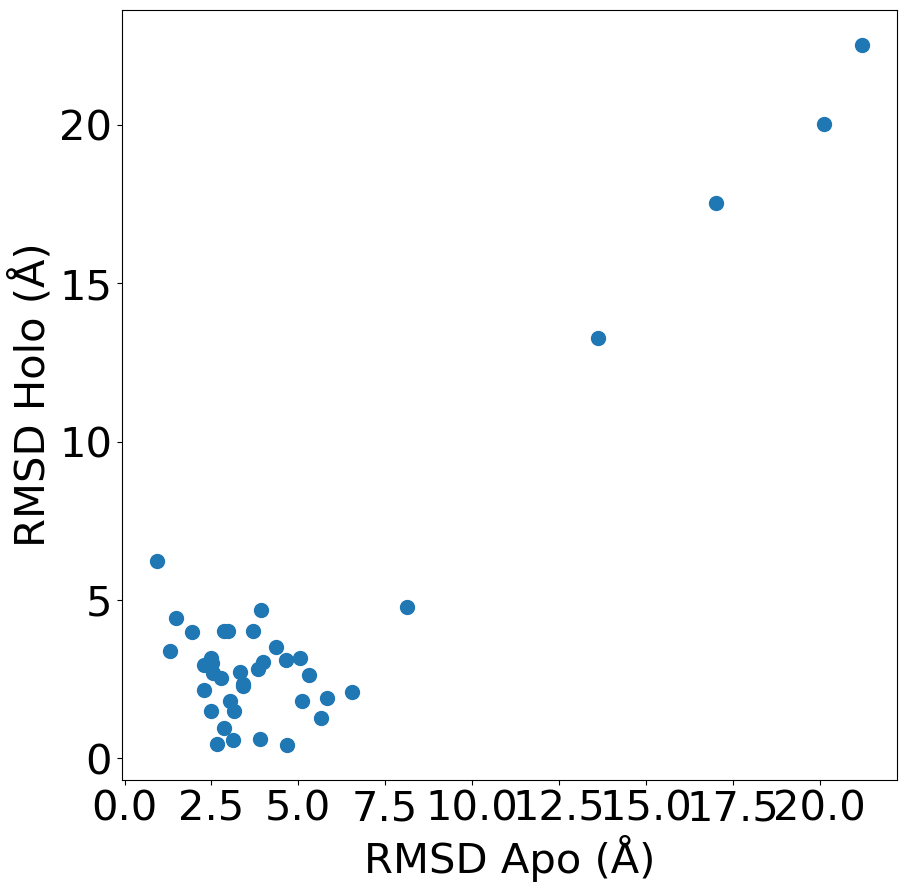

In [16]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,10))
plt.scatter(result_pair['RMSD'],result_pair['RMSD_pair'],s=100)
plt.xlabel('RMSD Apo (Å)',fontsize=30)
plt.ylabel('RMSD Holo (Å)',fontsize=30)
plt.yticks(fontsize=30)
plt.xticks(fontsize=30)
#plt.savefig('RMSD.png')

In [19]:
AlphaFold_df=pd.read_csv('AlphaFold_RMSD.csv',index_col='ID')
AlphaFold_df=AlphaFold_df.drop(AlphaFold_df.columns[0], axis=1)

In [20]:
AlphaFold_df['RMSD_Fold'] = pd.to_numeric(AlphaFold_df['RMSD_Fold'], errors='coerce')

In [21]:
AlphaFold_df=AlphaFold_df.dropna()

In [22]:
AlphaFold_dict=AlphaFold_df.to_dict()['RMSD_Fold']

In [23]:
result_pair.dtypes

ID            object
RMSD         float64
ID_pair       object
RMSD_pair    float64
dtype: object

In [24]:
AlphaFold_df.dtypes

RMSD_Fold    float64
dtype: object

In [25]:
for index, i in result_pair.iterrows():
    result_pair.loc[index,'RMSD']-=AlphaFold_dict[i['ID']]
    result_pair.loc[index,'RMSD_pair']-=AlphaFold_dict[i['ID_pair']]

(array([-8., -6., -4., -2.,  0.,  2.,  4.]),
 [Text(-8.0, 0, '−8'),
  Text(-6.0, 0, '−6'),
  Text(-4.0, 0, '−4'),
  Text(-2.0, 0, '−2'),
  Text(0.0, 0, '0'),
  Text(2.0, 0, '2'),
  Text(4.0, 0, '4')])

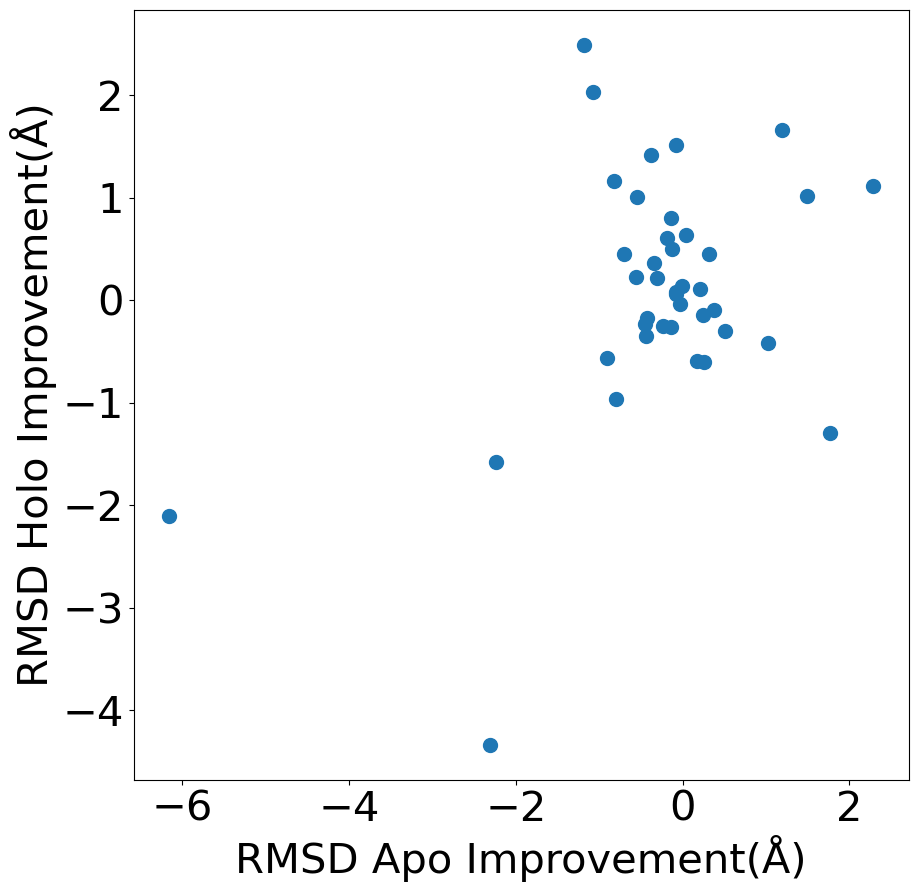

In [26]:
plt.figure(figsize=(10,10))
plt.scatter(result_pair['RMSD'],result_pair['RMSD_pair'],s=100)
plt.xlabel('RMSD Apo Improvement(Å)',fontsize=30)
plt.ylabel('RMSD Holo Improvement(Å)',fontsize=30)
plt.yticks(fontsize=30)
plt.xticks(fontsize=30)

In [28]:
result_pair['RMSD_sum']=result_pair['RMSD']+result_pair['RMSD_pair']

In [32]:
result_pair.sort_values('RMSD_sum')

,ID,RMSD,ID_pair,RMSD_pair,RMSD_sum
15,1JFJ-3_A,-6.162395,1JFK_A,-2.109873,-8.272268
28,4AKE_B,-2.313638,2ECK_B,-4.337800,-6.651437
13,1MO7-3_A,-2.238847,1MO8-14_A,-1.583627,-3.822474
6,1TJD_A,-0.797425,1EEJ_B,-0.969317,-1.766742
25,1FMF-4_A,-0.902580,1ID8-11_A,-0.568527,-1.471107
14,1VIY_C,-0.440276,1VHL_A,-0.355732,-0.796008
16,1LIP-2_A,-0.450644,1JTB-6_A,-0.233744,-0.684389
23,1WD7_B,-0.426444,1WCW_A,-0.177141,-0.603586
29,1GH1-7_A,-0.236910,1CZ2-8_A,-0.257443,-0.494353
0,1XSA-23_A,0.175216,1XSC-20_A,-0.599066,-0.423850
